<a href="https://colab.research.google.com/github/eragimovieu/ML-fundamentals-2026/blob/main/Assignment_1_ElshanRagimov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay


**Task 1: Identifying the Prediction Target**


The target variable is y that represents whether the client would subscribe to a term deposit or no via marketing campaign. It directly shows the outcome the bank is trying to anticipate, so I'd consider this the appropriate prediction objective.

**Two other variables that could superficially appear to be valid targets, but they should not be treated as the prediction objective:**

1. **duration** (call duration in seconds)
This could appear as a target since longer calls are strongly correlated with subscription. However, duration is not known before the call is made. It is only recorded after the conversation ends. This makes it a source of data leakage and it should be removed entirely from the feature set.

2. **poutcome** could appear to be a valid target since it represents a campaign outcome. However, it is unreliable for new clients who have no previous campaign history.

**Task 2: Data Loading and Exploration**

I chose this task as 2nd step because we need to understand the dataset's structure, distributions and potential issues before making any preprocessing decisions.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional.csv to bank-additional.csv


In [4]:
df = pd.read_csv('bank-additional.csv', sep=';')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


**Dataset Structure:**

Number of observations - 4119

Number of features - 21

Data types - int64 (whole numbers), float64 (decimal numbers), object (categorical)

Numerical columns (10): age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

Categorical columns (11): job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y

**Basic summary statistics:**

Most were contacted only a few times during the campaign, though some were contacted up to 35 times. The pdays column is mostly 999, which is a value meaning the client was never previously contacted. Duration varies a lot(0 to over 3600 seconds).



**Target variable distribution**

In [8]:
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True)*100)

y
no     3668
yes     451
Name: count, dtype: int64
y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


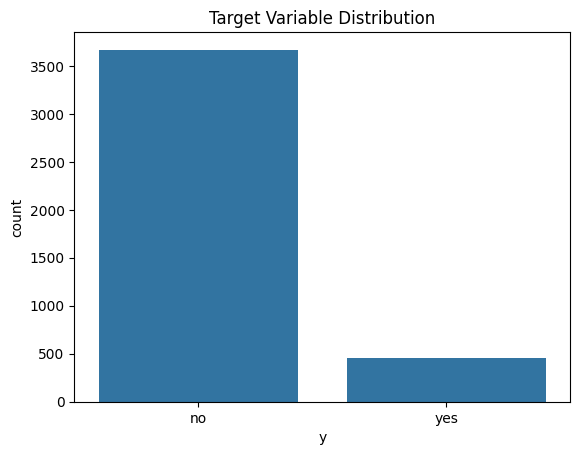

In [9]:
sns.countplot(x='y', data=df)
plt.title('Target Variable Distribution')
plt.show()

The target value is highly imbalanced (89% of clients said 'no', while only 11% said yes). So reallistically speaking, lazy model could just guess 'no' every time and get 89% accuracy.

This imbalance needs to be fixed during training, and we should pay more attention to metrics like **recall**(out of everyone who actually subscribed, how many did your model catch) and **precision**(out of everyone model predicted as "yes", how many actually subscribed) than to accuracy alone.

In [10]:
print("Explicit missing values:")
print(df.isnull().sum())

print("\nImplicit missing values ('unknown'):")
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count} ({count/len(df)*100:.1f}%)")

Explicit missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Implicit missing values ('unknown'):
job: 39 (0.9%)
marital: 11 (0.3%)
education: 167 (4.1%)
default: 803 (19.5%)
housing: 105 (2.5%)
loan: 105 (2.5%)


No explicit missing values in in the dataset, but 6 columns contain implicit missing values represented as "unknown".

The column that got affected the most is default with 19.5% unknown values.

The remaining columns have relatively low missingness.

These implicit missing values will be handled in the preprocessing stage.

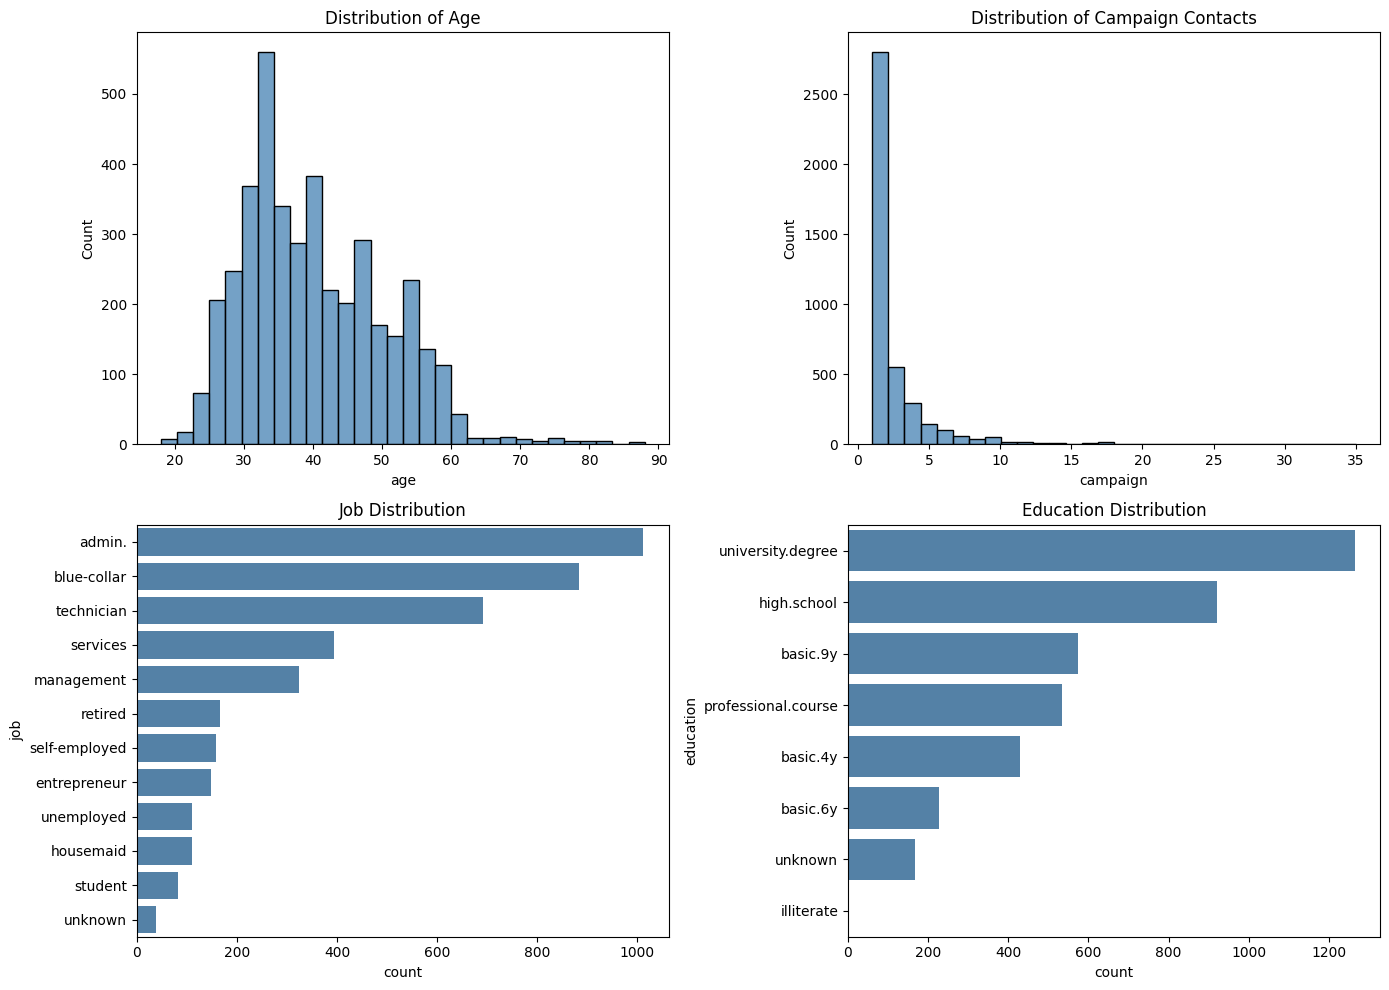

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Numerical age distribution
sns.histplot(df['age'], bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Age')

# Numerical campaign contacts
sns.histplot(df['campaign'], bins=30, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Distribution of Campaign Contacts')

# Categorical job
sns.countplot(y='job', data=df, ax=axes[1,0], color='steelblue',
              order=df['job'].value_counts().index)
axes[1,0].set_title('Job Distribution')

# Categorical education
sns.countplot(y='education', data=df, ax=axes[1,1], color='steelblue',
              order=df['education'].value_counts().index)
axes[1,1].set_title('Education Distribution')

plt.tight_layout()
plt.show()

Age peaks around 30-40 with a tail towards older clients.

Most clients were contacted only once or twice, with a few outliers reaching 35 contacts.

Admin and blue-collar are the dominant job types, and university degree is the most common education level.

**Variable that may require special consideration before modeling**

As I mentioned before, duration requires special consideration as it represents the call duration, which is only known after the call has ended. Using it as a feature would introduce data leakage, so it must be removed from the dataset before modeling.

**Task 3: Task Ordering**

The order I chose and justification:

1. Identifying the Prediction Target — must come first because we should know what we are trying to predict.
2. Data Loading and Exploration — comes before any preprocessing, so we can understand the dataset's structure and identify potential issues.
3. Task Ordering — should come after we are already familiar with data and it's structure but before preprocessing.
4. Data Splitting — must happen before any preprocessing to avoid data leakage.
5. Managing Missing Values — comes before encoding since encoding shouldn't have data with "unknown" values.
6. Encoding Categorical Variables — scalers only work on numerical values, so encoding must be before that
7. Feature Scaling — applied after encoding so all features are numerical and comparable.
8. Feature Selection — performed after scaling so variance and correlation are measured on the final numerical representation.
9. Addressing Class Imbalance — applied right before training only on the training set. Resampling before splitting would introduce synthetic data into the test set, making evaluation unreliable.
10. Training Logistic Regression — a sanity check.

All operations that learn from data (imputation, encoding, scaling, feature selection, resampling) must be fitted on the training set only. Fitting on the full dataset leaks test set information into training, and it makes evaluation unreliable.

**Example of incorrect ordering:** If we apply SMOTE (saw in class) before splitting, some of the artificial data it created would end up in the test set. The test set should only contain real clients — so evaluating on fake data would make our model look better than it actually is.

**Task 4: Data Splitting**





In [12]:
# Separate features and target
X = df.drop(columns=['y', 'duration'])
y = df['y']

# Splitting into temporary(30%) and traning (70%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Splitting temporary into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Verify class distribution
print(f"\nTraining class distribution:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nValidation class distribution:\n{y_val.value_counts(normalize=True)*100}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True)*100}")

Training set: 2883 samples
Validation set: 618 samples
Test set: 618 samples

Training class distribution:
y
no     89.039195
yes    10.960805
Name: proportion, dtype: float64

Validation class distribution:
y
no     88.996764
yes    11.003236
Name: proportion, dtype: float64

Test class distribution:
y
no     89.158576
yes    10.841424
Name: proportion, dtype: float64


 The dataset was first splitted into training (70%) and a temporary set (30%), then the temporary set was equally splitted into validation and test. 70% training size is enough data to learn from, and 15% each for validation and test is enough samples for reliable evaluation.

 Stratification is used so the class imbalance is preserved across all splits. Without it, some sets might end up with very few "yes" examples.

 Splitting is done before any preprocessing because if we split later, test set values would influence things like imputation and scaling, which would be data leakage. The test set must be kept untouched until final evaluation.

**Task 5: Managing Missing Values**

In [13]:
#pdays sentinel value
X_train['was_contacted_before'] = (X_train['pdays'] != 999).astype(int)
X_val['was_contacted_before'] = (X_val['pdays'] != 999).astype(int)
X_test['was_contacted_before'] = (X_test['pdays'] != 999).astype(int)

# Drop pdays because I replaced it by the binary indicator
X_train = X_train.drop(columns=['pdays'])
X_val = X_val.drop(columns=['pdays'])
X_test = X_test.drop(columns=['pdays'])

# Check remaining implicit missing values
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Keep 'unknown' as a separate category
for col in unknown_cols:
    count = (X_train[col] == 'unknown').sum()
    print(f"{col}: {count} unknown values in training set")

job: 25 unknown values in training set
marital: 7 unknown values in training set
education: 112 unknown values in training set
default: 577 unknown values in training set
housing: 65 unknown values in training set
loan: 65 unknown values in training set


As mentioned before, no explicit missing values were found. 6 columns contain "unknown" values which I decided to keep as a separate category rather than imputing (modeling decision). I was concered about imputation because some columns have to many of "uknown" values to just invent information we don't have.

pdays used 999 to mean "never contacted before", so I replaced it with a simpler binary column "was_contacted_before" and dropped pdays (data cleaning decision).

All of this was done using training data only to avoid leakage.

Based on task 2 (just took 70% of numbers I got there), the unknown values per column in the training set are: job (25), marital (7), education (112), default (577), housing (65), loan (65).

**Task 6: Encoding Categorical Variables**

In [14]:
# Define ordinal and nominal columns
ordinal_cols = ['education']
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

# Ordinal encoding for education
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree', 'unknown']

ordinal_encoder = OrdinalEncoder(categories=[education_order])
X_train['education'] = ordinal_encoder.fit_transform(X_train[['education']])
X_val['education'] = ordinal_encoder.transform(X_val[['education']])
X_test['education'] = ordinal_encoder.transform(X_test[['education']])

# One-hot encoding for nominal columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded = ohe.fit_transform(X_train[nominal_cols])
val_encoded = ohe.transform(X_val[nominal_cols])
test_encoded = ohe.transform(X_test[nominal_cols])

# Convert to dataframes and join back
encoded_cols = ohe.get_feature_names_out(nominal_cols)
X_train = X_train.drop(columns=nominal_cols).reset_index(drop=True)
X_val = X_val.drop(columns=nominal_cols).reset_index(drop=True)
X_test = X_test.drop(columns=nominal_cols).reset_index(drop=True)

X_train = pd.concat([X_train, pd.DataFrame(train_encoded, columns=encoded_cols)], axis=1)
X_val = pd.concat([X_val, pd.DataFrame(val_encoded, columns=encoded_cols)], axis=1)
X_test = pd.concat([X_test, pd.DataFrame(test_encoded, columns=encoded_cols)], axis=1)

print(f"Dataset shape after encoding: {X_train.shape}")

Dataset shape after encoding: (2883, 55)


I splitted categorical columns into ordinal and nominal.

"education" is the only ordinal variable because education levels have a clear progression.

All other categorical columns are nominal with no natural order existing,so I applied one-hot encoding and created a binary column for each category. This increased the dataset from 19 to 55 columns.

To avoid leakage both encoders were fitted on training data only. Each category gets its own coefficient in Logistic Regression, so results could be interpretable. However, Logistic Regression is a linear model, so encoding does not change the fact that it can only draw linear decision boundaries.

**Task 7: Feature Scaling**

In [15]:
# Numerical columns to scale
numerical_cols = ['age', 'campaign', 'previous', 'emp.var.rate',
                  'cons.price.idx', 'cons.conf.idx', 'euribor3m',
                  'nr.employed', 'education']

# Apply StandardScaler
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaling complete!")
print(f"\nMean of scaled training features (should be ~0):")
print(X_train[numerical_cols].mean().round(2))
print(f"\nStd of scaled training features (should be ~1):")
print(X_train[numerical_cols].std().round(2))

Scaling complete!

Mean of scaled training features (should be ~0):
age              -0.0
campaign         -0.0
previous          0.0
emp.var.rate     -0.0
cons.price.idx   -0.0
cons.conf.idx     0.0
euribor3m        -0.0
nr.employed       0.0
education        -0.0
dtype: float64

Std of scaled training features (should be ~1):
age               1.0
campaign          1.0
previous          1.0
emp.var.rate      1.0
cons.price.idx    1.0
cons.conf.idx     1.0
euribor3m         1.0
nr.employed       1.0
education         1.0
dtype: float64


I applied standardization to all numerical columns. I didn't do anything with binary columns because they're already on a 0-1 scale.

I chose StandardScaler because it transforms each column to have mean=0 and std=1. MinMaxScaler is too sensitive to outliers, and because columns like campaign have extreme values, StandardScaler is the safer choice.

Without scaling, features with larger ranges would dominate the optimization. Finally, regularization penalties are applied fairly across all features only when they're on the same scale.

To avoid leakage the scaler was only fitted on training data.

**Task 8: Feature Selection**

Low variance features (var < 0.01):
job_unknown        0.008599
marital_unknown    0.002423
default_yes        0.000347
month_dec          0.005864
dtype: float64


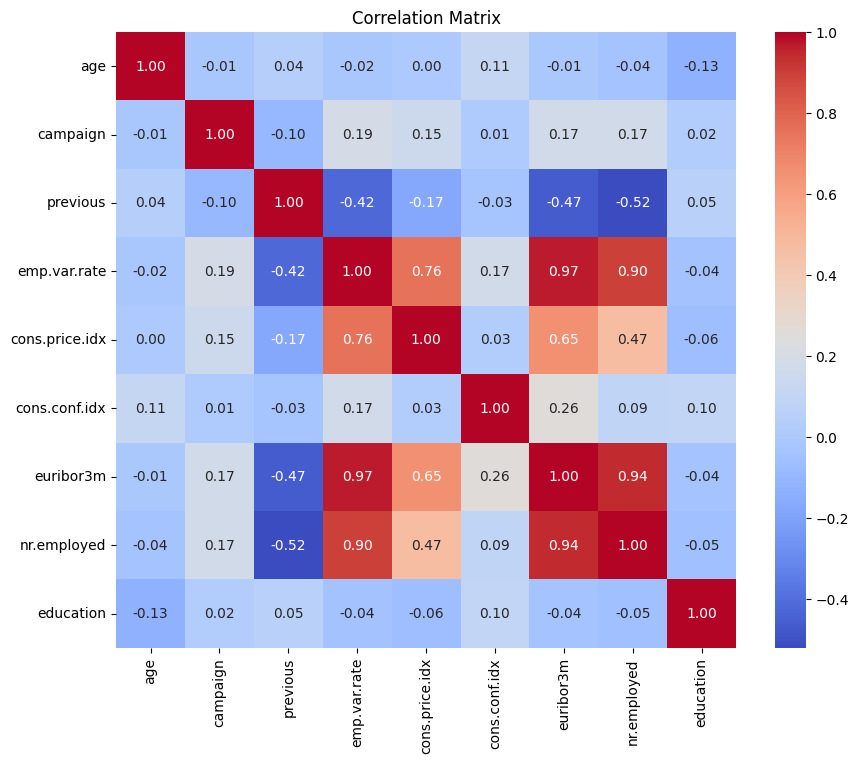


Highly correlated pairs (|correlation| > 0.85):
emp.var.rate & euribor3m: 0.97
emp.var.rate & nr.employed: 0.90
euribor3m & nr.employed: 0.94


In [16]:
# Variance
variance = X_train.var()
print("Low variance features (var < 0.01):")
print(variance[variance < 0.01])

# Check correlation between numerical features
numerical_cols_current = ['age', 'campaign', 'previous',
                          'emp.var.rate', 'cons.price.idx',
                          'cons.conf.idx', 'euribor3m',
                          'nr.employed', 'education']

corr_matrix = X_train[numerical_cols_current].corr()

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Show highly correlated pairs
print("\nHighly correlated pairs (|correlation| > 0.85):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.85:
            print(f"{corr_matrix.columns[i]} & {corr_matrix.columns[j]}: {corr_matrix.iloc[i,j]:.2f}")

In [17]:
# Remove low variance features
low_var_cols = ['job_unknown', 'marital_unknown', 'default_yes', 'month_dec']
X_train = X_train.drop(columns=low_var_cols)
X_val = X_val.drop(columns=low_var_cols)
X_test = X_test.drop(columns=low_var_cols)

# Remove highly correlated features (keep emp.var.rate, drop the other two)
high_corr_cols = ['euribor3m', 'nr.employed']
X_train = X_train.drop(columns=high_corr_cols)
X_val = X_val.drop(columns=high_corr_cols)
X_test = X_test.drop(columns=high_corr_cols)

print(f"Dataset shape after feature selection:{X_train.shape}")

Dataset shape after feature selection:(2883, 49)


I removed 4 features ('job_unknown', 'marital_unknown', default_yes', 'month_dec') because of very low variance (below 0.01). They were almost always 0 and add noise rather than useful information.

3 features were highly correlated (above 0.85) because they all reflect the same economic conditions, so 'euribor3m' and 'nr.employed' were dropped but 'emp.var.rate' was kept.

I chose the 0.85 threshold because beyond this point features become redundant for a linear model.

 'duration' was already removed earlier because it's not available at prediction time.

 Having correlated features hurts Logistic Regression because it makes coefficients unstable.

 Feature selection was done only on training data. Doing it on the full dataset would let test set statistics influence which features are kept, making evaluation unreliable.

**Task 9: Addressing Class Imbalance**

In [18]:
# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {y_train_resampled.value_counts().to_dict()}")

Before SMOTE: {'no': 2567, 'yes': 316}
After SMOTE: {'no': 2567, 'yes': 2567}


The training set had 2567 "no" and only 316 "yes" examples. That's a clear imbalance.

I applied SMOTE to fix this by creating synthetic "yes" examples through interpolation instead of just duplicating existing ones.I did it only after all preprocessing and only on the training set (doing it before splitting would put fake data into the test set).

As I mentioned before, because of the imbalance, accuracy alone is misleading. Lay model can just predict "no" and get 89% accuracy. Precision and recall are more useful metrics here.

**Task 10: Training Logistic Regression**

Accuracy:  0.803
Precision: 0.312
Recall:    0.662

Zero Rule baseline accuracy: 0.890


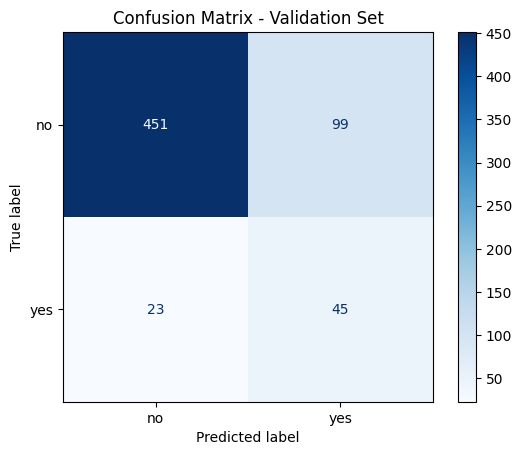

In [20]:
# Train model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

# Predict on validation set
y_pred = lr.predict(X_val)

# Metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, pos_label='yes')
recall = recall_score(y_val, y_pred, pos_label='yes')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

# Zero Rule baseline
zero_rule = y_val.value_counts(normalize=True).max()
print(f"\nZero Rule baseline accuracy: {zero_rule:.3f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Validation Set')
plt.show()

The model has 80.3% accuracy. It's is lower than the Zero Rule baseline of 89%. But I expected this because the model now actively tries to identify subscribers instead of just predicting "no".

Recall of 66% means the model catches most actual subscribers.

The model achieved precision of 31%. It means that some false positives exist, but this is acceptable given the class imbalance.

**AI statement**

In this assignenment I used AI to teach me, not to write code instead of me, or not to make the descisions regarding the model.

I used AI to choose which libraries do I need to use, to help me with making the charts, making sure that StandardScaler is the best tool I can use in that spesific task, and fixing the code in some tasks.

